# 04 Construct Calibrated Likelihood Layer

## Objective
Construct a calibrated likelihood layer from the boosting-model walk-forward probabilities, then validate it with probability diagnostics before the Bayesian update step.

## Pipeline Position

This notebook converts the model probabilities from the 03-series modeling workflow into a
calibrated likelihood table. It exports `calibration_map.csv` and `final_results_cache.pkl`,
which notebook 05 loads for the final Bayesian update.

**Features used** (all lagged to prevent leakage):
- Lagged upper bound fed funds rate (`target_rate_lag1` to `target_rate_lag4`, plus `lagged_upper_bound`)
- PCE inflation gap (`PCE_inflation_gap_lag1` to `PCE_inflation_gap_lag4`)
- Unemployment gap (`unemployment_gap_lag1` to `unemployment_gap_lag4`)
- Output gap (`output_gap_pct_lag1` to `output_gap_pct_lag4`)
- Financial conditions (`NFCI_lag1` to `NFCI_lag4`)
- Derived change / policy inertia features

## Test Methodology: Walk-Forward (Expanding Window) Validation
For each FOMC meeting at index $t$, starting from `INITIAL_TRAIN_SIZE = 40`:
1. Train on all meetings $[0, t)$
2. Predict **probability distribution** $[P(\text{Lower}), P(\text{Same}), P(\text{Higher})]$ for meeting $t$
3. Record distribution -> advance $t$ by 1

## Models and Soft-Probability Method
| Model | Soft-probability method |
|---|---|
| **XGBoost** | `objective='multi:softprob'` -> `predict_proba()` |
| **LightGBM** | `predict_proba()` |
| **CatBoost** | `predict_proba()` |
| **HistGradientBoosting** | `predict_proba()` |

Hyperparameters are **pre-tuned via Optuna** in `03_boosting_models_trained_on_economic_variables.ipynb` and hardcoded here.

## Evaluation Metrics
| Metric | Purpose |
|---|---|
| Accuracy / F1 Macro | Hard-label quality (argmax of probs) |
| **Brier Score** | Probability calibration (lower = better) |
| **Log-Loss** | Entropy of predicted distributions (lower = better) |

> **Class imbalance note:** most meetings are still `Same`.
> All models use balanced class weights where supported. **F1 Macro** is the primary hard-label metric.

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, log_loss, brier_score_loss
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'analysis':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.catboost_artifacts import (
    catboost_artifact_available,
    load_04_artifact,
)
from modeling.notebook_io import resolve_data_source

# ── Optional packages ─────────────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed — skipping')

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not installed — skipping')

CATBOOST_AVAILABLE = catboost_artifact_available(PROJECT_ROOT, '04_calibrated_likelihood.json')
catboost_bundle_04 = load_04_artifact(PROJECT_ROOT) if CATBOOST_AVAILABLE else None
if not CATBOOST_AVAILABLE:
    print('CatBoost artifacts not found — run: python scripts/build_catboost_artifacts.py')

print('All imports OK')
print(f'  XGBoost : {XGBOOST_AVAILABLE}')
print(f'  LightGBM: {LGBM_AVAILABLE}')
print(f'  CatBoost: {CATBOOST_AVAILABLE}')

All imports OK
  XGBoost : True
  LightGBM: True
  CatBoost: True


---
## 1. Data Loading & Feature Setup

In [2]:
_DATA_URL = resolve_data_source('df_model.csv', PROJECT_ROOT)
df_model = pd.read_csv(_DATA_URL, parse_dates=['meeting_date'])

print(f'Loaded df_model: {df_model.shape[0]} rows × {df_model.shape[1]} columns')
print(f'Date range     : {df_model["meeting_date"].min().date()} → {df_model["meeting_date"].max().date()}')
print()
print('Decision distribution:')
print(df_model['decision'].value_counts())

Loaded df_model: 136 rows × 32 columns
Date range     : 2009-08-12 → 2026-01-28

Decision distribution:
decision
same      105
higher     20
lower      11
Name: count, dtype: int64


In [3]:
# ── Feature / Label Setup ─────────────────────────────────────────────────────
NON_FEATURE_COLS = ['meeting_date', 'decision', 'decision_num', 'prev_decision']
feature_cols = [c for c in df_model.columns if c not in NON_FEATURE_COLS]

X = df_model[feature_cols].values.astype(float)      # shape (N, n_features)
y_orig = df_model['decision_num'].values.astype(int)  # -1 = Lower, 0 = Same, 1 = Higher
meeting_dates = df_model['meeting_date'].values

# XGBoost / LightGBM / CatBoost require 0-indexed integer labels
LABEL_MAP     = {-1: 0,  0: 1,  1: 2}   # original → encoded
INV_LABEL_MAP = { 0: -1, 1: 0,  2: 1}   # encoded  → original
ENCODED_NAMES = { 0: 'Lower', 1: 'Same', 2: 'Higher'}
LABEL_VALS    = [-1, 0, 1]
LABEL_STRS    = ['Lower', 'Same', 'Higher']
# Encoded order: 0=Lower, 1=Same, 2=Higher

y_enc = np.array([LABEL_MAP[v] for v in y_orig])    # 0, 1, 2

print(f'Features: {len(feature_cols)}')
print(f'Samples : {len(X)}')
print(f'Label distribution (encoded): {dict(zip(*np.unique(y_enc, return_counts=True)))}')
print('  0=Lower, 1=Same, 2=Higher')

Features: 28
Samples : 136
Label distribution (encoded): {0: 11, 1: 105, 2: 20}
  0=Lower, 1=Same, 2=Higher


---
## 2. Best Hyperparameters (from Optuna in `03_boosting_models_trained_on_economic_variables.ipynb`)

In [4]:
# ── Pre-tuned hyperparameters (Optuna, 03_boosting_models_trained_on_economic_variables.ipynb) ─────────────────
BEST_PARAMS = {
    'XGBoost': dict(
        n_estimators     = 471,
        max_depth        = 3,
        learning_rate    = 0.161042,
        subsample        = 0.712890,
        colsample_bytree = 0.847161,
        min_child_weight = 3,
        gamma            = 0.360274,
        reg_alpha        = 0.243105,
        reg_lambda       = 3.207902,
    ),
    'LightGBM': dict(
        n_estimators      = 500,
        num_leaves        = 42,
        learning_rate     = 0.056209,
        subsample         = 0.685067,
        colsample_bytree  = 0.849375,
        min_child_samples = 17,
        reg_alpha         = 0.658121,
        reg_lambda        = 3.342565,
    ),
    'CatBoost': dict(catboost_bundle_04['best_params']) if CATBOOST_AVAILABLE else {},
    'HistGradientBoosting': dict(
        max_iter          = 478,
        max_depth         = 4,
        learning_rate     = 0.036259,
        min_samples_leaf  = 3,
        l2_regularization = 2.391524,
        max_leaf_nodes    = 38,
    ),
}

print('Pre-tuned hyperparameters loaded:')
for name, params in BEST_PARAMS.items():
    print(f'  {name}: {params}')

Pre-tuned hyperparameters loaded:
  XGBoost: {'n_estimators': 471, 'max_depth': 3, 'learning_rate': 0.161042, 'subsample': 0.71289, 'colsample_bytree': 0.847161, 'min_child_weight': 3, 'gamma': 0.360274, 'reg_alpha': 0.243105, 'reg_lambda': 3.207902}
  LightGBM: {'n_estimators': 500, 'num_leaves': 42, 'learning_rate': 0.056209, 'subsample': 0.685067, 'colsample_bytree': 0.849375, 'min_child_samples': 17, 'reg_alpha': 0.658121, 'reg_lambda': 3.342565}
  CatBoost: {'iterations': 331, 'depth': 2, 'learning_rate': 0.018522, 'l2_leaf_reg': 3.272855, 'bagging_temperature': 0.324958}
  HistGradientBoosting: {'max_iter': 478, 'max_depth': 4, 'learning_rate': 0.036259, 'min_samples_leaf': 3, 'l2_regularization': 2.391524, 'max_leaf_nodes': 38}


---
## 3. Walk-Forward Validation Helpers (Probability Output)

In [5]:
INITIAL_TRAIN_SIZE = 40


def augment_missing_classes(X_train, y_train, all_classes=(0, 1, 2)):
    """
    Inject one synthetic sample per missing class (mean features, low weight).
    Ensures all 3 classes are always present while keeping synthetic rows low-priority.
    Returns (X_aug, y_aug, sample_weights).
    """
    present = set(y_train)
    missing = set(all_classes) - present

    class_counts = np.bincount(y_train, minlength=3)
    n_total      = len(y_train)
    real_weights = np.array([n_total / (3 * max(class_counts[c], 1)) for c in y_train],
                             dtype=float)

    if not missing:
        return X_train, y_train, real_weights

    X_mean       = X_train.mean(axis=0, keepdims=True)
    X_synth      = np.vstack([X_mean] * len(missing))
    y_synth      = np.array(sorted(missing))
    synth_weight = float(real_weights.min()) * 0.1
    w_synth      = np.full(len(missing), synth_weight, dtype=float)

    return (np.vstack([X_train, X_synth]),
            np.concatenate([y_train, y_synth]),
            np.concatenate([real_weights, w_synth]))


def walk_forward_proba(
    fit_fn,
    proba_fn,
    X, y_enc,
    n_start=INITIAL_TRAIN_SIZE,
    verbose=True
):
    """
    Expanding-window walk-forward validation that collects probability distributions.

    Returns
    -------
    actuals_enc : np.array (N_test,)    — true encoded labels {0,1,2}
    probas      : np.array (N_test, 3)  — P(Lower), P(Same), P(Higher) per meeting
    """
    actuals, probas = [], []
    total = len(X) - n_start

    for t in range(n_start, len(X)):
        X_train, y_train = X[:t], y_enc[:t]
        X_test           = X[t:t+1]

        model  = fit_fn(X_train, y_train)
        p_dist = proba_fn(model, X_test)   # shape (1, 3)

        actuals.append(y_enc[t])
        probas.append(p_dist[0])           # shape (3,)

        done = t - n_start + 1
        if verbose and (done % 25 == 0 or done == total):
            p = p_dist[0]
            pred_enc = int(np.argmax(p))
            flag = '✓' if y_enc[t] == pred_enc else '✗'
            print(
                f'  [{done:3d}/{total}]  '
                f'{pd.Timestamp(meeting_dates[t]).date()}  '
                f'true={ENCODED_NAMES[y_enc[t]]:7s}  '
                f'pred={ENCODED_NAMES[pred_enc]:7s}  {flag}  '
                f'[L={p[0]:.2f} S={p[1]:.2f} H={p[2]:.2f}]'
            )

    return np.array(actuals), np.vstack(probas)   # (N,), (N, 3)


def report_prob_metrics(name, actuals_enc, probas):
    """Compute and print metrics for a probabilistic classifier. Returns a results dict."""
    preds_enc    = np.argmax(probas, axis=1)
    actuals_orig = np.array([INV_LABEL_MAP[a] for a in actuals_enc])
    preds_orig   = np.array([INV_LABEL_MAP[p] for p in preds_enc])

    acc    = accuracy_score(actuals_orig, preds_orig)
    f1_mac = f1_score(actuals_orig, preds_orig, labels=LABEL_VALS,
                      average='macro', zero_division=0)
    f1_wt  = f1_score(actuals_orig, preds_orig, labels=LABEL_VALS,
                      average='weighted', zero_division=0)

    y_onehot = label_binarize(actuals_enc, classes=[0, 1, 2])
    logloss  = log_loss(actuals_enc, probas, labels=[0, 1, 2])
    brier    = np.mean([
        brier_score_loss(y_onehot[:, k], probas[:, k])
        for k in range(3)
    ])

    n_test  = len(actuals_orig)
    n_right = int(acc * n_test)

    print('=' * 68)
    print(f'  {name}')
    print('=' * 68)
    print(f'  Accuracy     : {acc:.4f}  ({n_right}/{n_test} correct)')
    print(f'  F1 Macro     : {f1_mac:.4f}  (primary hard-label metric)')
    print(f'  F1 Weighted  : {f1_wt:.4f}')
    print(f'  Log-Loss     : {logloss:.4f}  (↓ better calibration)')
    print(f'  Brier Score  : {brier:.4f}   (↓ better calibration)')
    print()
    print(classification_report(actuals_orig, preds_orig, labels=LABEL_VALS,
                                  target_names=LABEL_STRS, zero_division=0))

    return dict(
        name=name,
        accuracy=acc, f1_macro=f1_mac, f1_weighted=f1_wt,
        log_loss=logloss, brier_score=brier,
        actuals_enc=actuals_enc, preds_enc=preds_enc,
        actuals_orig=actuals_orig, preds_orig=preds_orig,
        probas=probas,
    )


print('Helpers defined.')

Helpers defined.


---
## 4. Walk-Forward Probabilistic Evaluation

Each model returns `[P(Lower), P(Same), P(Higher)]` at every FOMC meeting using the pre-tuned hyperparameters.

In [6]:
# ── 4-cache: Load or Init ─────────────────────────────────────────────────────
# • If a pickle cache exists → loads all model results instantly, no retraining.
# • If no cache → initialises empty final_results; training cells below will run.
# • To force a full re-train: delete `final_results_cache.pkl`, then re-run from this cell.
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path
import pickle as _pkl

_CACHE_PATH = Path('final_results_cache.pkl')

final_results = {}   # always start clean; populated from cache below if available

if _CACHE_PATH.exists():
    with _CACHE_PATH.open('rb') as _f:
        _cache = _pkl.load(_f)
    final_results = _cache.get('final_results', {})
    # Restore library-availability flags
    if 'XGBOOST_AVAILABLE'  in _cache: XGBOOST_AVAILABLE  = _cache['XGBOOST_AVAILABLE']
    if 'LGBM_AVAILABLE'     in _cache: LGBM_AVAILABLE     = _cache['LGBM_AVAILABLE']
    # Restore global prob_* / act_* so every downstream cell works without retraining
    if 'XGBoost'              in final_results:
        prob_xgb  = final_results['XGBoost']['probas']
        act_xgb   = final_results['XGBoost']['actuals_enc']
    if 'LightGBM'             in final_results:
        prob_lgbm = final_results['LightGBM']['probas']
        act_lgbm  = final_results['LightGBM']['actuals_enc']
    if 'CatBoost'             in final_results:
        prob_cat  = final_results['CatBoost']['probas']
        act_cat   = final_results['CatBoost']['actuals_enc']
    if 'HistGradientBoosting' in final_results:
        prob_hgb  = final_results['HistGradientBoosting']['probas']
        act_hgb   = final_results['HistGradientBoosting']['actuals_enc']
    print(f'✅ Cache loaded  →  {_CACHE_PATH}')
    print(f'   Models: {list(final_results.keys())}')
    print('   ↳ Training cells 4a–4d will auto-skip for cached models.')
    print('   ↳ To force re-train: delete cache file, re-run from this cell.')
else:
    print(f'ℹ️  No cache found at {_CACHE_PATH}')
    print('   Run training cells 4a–4d to train models.')
    print('   Cache will be auto-saved after cell 4d finishes.')


ℹ️  No cache found at final_results_cache.pkl
   Run training cells 4a–4d to train models.
   Cache will be auto-saved after cell 4d finishes.


In [7]:
# ── 4a. XGBoost ───────────────────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    bp = BEST_PARAMS['XGBoost']

    def xgb_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = XGBClassifier(
            **bp,
            objective='multi:softprob',
            num_class=3,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=42, verbosity=0
        )
        m.fit(Xa, ya, sample_weight=sw)
        return m

    def xgb_proba(m, Xt):
        """Returns shape (1, 3): [P(Lower), P(Same), P(Higher)]"""
        return m.predict_proba(Xt)

    if 'XGBoost' not in final_results:
        t0 = time.time()
        print('Running XGBoost walk-forward …')
        act_xgb, prob_xgb = walk_forward_proba(xgb_fit, xgb_proba, X, y_enc, verbose=False)
        r = report_prob_metrics('XGBoost', act_xgb, prob_xgb)
        final_results['XGBoost'] = r
        print(f'  ↳ done in {time.time()-t0:.1f}s\n')
    else:
        print('✅ XGBoost already in final_results (cached) — skipping training.')
        prob_xgb = final_results['XGBoost']['probas']
        act_xgb  = final_results['XGBoost']['actuals_enc']
else:
    print('XGBoost not available — skipping.')


Running XGBoost walk-forward …


  XGBoost
  Accuracy     : 0.6354  (61/96 correct)
  F1 Macro     : 0.5801  (primary hard-label metric)
  F1 Weighted  : 0.6533
  Log-Loss     : 1.0096  (↓ better calibration)
  Brier Score  : 0.1902   (↓ better calibration)

              precision    recall  f1-score   support

       Lower       0.50      0.45      0.48        11
        Same       0.89      0.60      0.72        65
      Higher       0.40      0.85      0.55        20

    accuracy                           0.64        96
   macro avg       0.60      0.63      0.58        96
weighted avg       0.74      0.64      0.65        96

  ↳ done in 114.5s



In [8]:
# ── 4b. LightGBM ──────────────────────────────────────────────────────────────
if LGBM_AVAILABLE:
    bp = BEST_PARAMS['LightGBM']

    def lgbm_fit(Xtr, ytr):
        # augment_missing_classes ensures all 3 labels are present so
        # predict_proba always returns shape (1, 3) — not (1, 2) when
        # the rare 'Lower' class is absent from early training windows.
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = LGBMClassifier(
            **bp,
            class_weight='balanced',
            random_state=42, verbose=-1, n_jobs=1
        )
        m.fit(Xa, ya, sample_weight=sw)
        return m

    def lgbm_proba(m, Xt):
        """Returns shape (1, 3): [P(Lower), P(Same), P(Higher)]"""
        return m.predict_proba(Xt)

    if 'LightGBM' not in final_results:
        t0 = time.time()
        print('Running LightGBM walk-forward …')
        act_lgbm, prob_lgbm = walk_forward_proba(lgbm_fit, lgbm_proba, X, y_enc, verbose=False)
        r = report_prob_metrics('LightGBM', act_lgbm, prob_lgbm)
        final_results['LightGBM'] = r
        print(f'  ↳ done in {time.time()-t0:.1f}s\n')
    else:
        print('✅ LightGBM already in final_results (cached) — skipping training.')
        prob_lgbm = final_results['LightGBM']['probas']
        act_lgbm  = final_results['LightGBM']['actuals_enc']
else:
    print('LightGBM not available — skipping.')


Running LightGBM walk-forward …


  LightGBM
  Accuracy     : 0.5521  (53/96 correct)
  F1 Macro     : 0.5354  (primary hard-label metric)
  F1 Weighted  : 0.5652
  Log-Loss     : 1.5870  (↓ better calibration)
  Brier Score  : 0.2569   (↓ better calibration)

              precision    recall  f1-score   support

       Lower       0.46      0.55      0.50        11
        Same       0.88      0.45      0.59        65
      Higher       0.36      0.90      0.51        20

    accuracy                           0.55        96
   macro avg       0.57      0.63      0.54        96
weighted avg       0.72      0.55      0.57        96

  ↳ done in 10.5s



In [9]:
# ── 4c. CatBoost ──────────────────────────────────────────────────────────────
if CATBOOST_AVAILABLE:
    final_results['CatBoost'] = dict(catboost_bundle_04['final_result'])
    prob_cat = final_results['CatBoost']['probas']
    act_cat = final_results['CatBoost']['actuals_enc']
    print('Loaded CatBoost walk-forward probabilities from artifacts.')
    print(
        f"  accuracy={final_results['CatBoost']['accuracy']:.4f}  "
        f"log_loss={final_results['CatBoost']['log_loss']:.4f}  "
        f"brier={final_results['CatBoost']['brier_score']:.4f}"
    )
else:
    print('CatBoost artifacts not available — skipping.')


Loaded CatBoost walk-forward probabilities from artifacts.
  accuracy=0.6458  log_loss=0.8381  brier=0.1613


In [10]:
# ── 4d. HistGradientBoosting ──────────────────────────────────────────────────
# Why this was slow (three compounding reasons):
#  1. sklearn's Cython backend is slower per split than XGBoost/LightGBM's C++.
#  2. Optuna tuned max_leaf_nodes=38 — ~4.7× more splits/tree vs XGBoost (depth=3→8 leaves).
#  3. No early stopping: all 478 rounds ran every fit, 95 fits = 45,410 boosting rounds.
#
# Fix: early_stopping enabled only when every class has ≥ 2 samples in Xa
# (sklearn's StratifiedShuffleSplit requires that; otherwise ValueError).

bp = BEST_PARAMS['HistGradientBoosting']

def hgb_fit(Xtr, ytr):
    Xa, ya, sw = augment_missing_classes(Xtr, ytr)
    _min_cls = int(np.bincount(ya, minlength=3).min())
    _use_es  = _min_cls >= 2
    m = HistGradientBoostingClassifier(
        **bp,
        class_weight='balanced',
        random_state=42,
        early_stopping=_use_es,
        validation_fraction=0.15,
        n_iter_no_change=20,
    )
    m.fit(Xa, ya, sample_weight=sw)
    return m

def hgb_proba(m, Xt):
    """Returns shape (1, 3): [P(Lower), P(Same), P(Higher)]"""
    return m.predict_proba(Xt)

if 'HistGradientBoosting' not in final_results:
    t0 = time.time()
    print('Running HistGradientBoosting walk-forward …')
    act_hgb, prob_hgb = walk_forward_proba(hgb_fit, hgb_proba, X, y_enc, verbose=True)
    r = report_prob_metrics('HistGradientBoosting', act_hgb, prob_hgb)
    final_results['HistGradientBoosting'] = r
    print(f'  ↳ done in {time.time()-t0:.1f}s\n')
else:
    print('✅ HistGradientBoosting already in final_results (cached) — skipping training.')
    prob_hgb = final_results['HistGradientBoosting']['probas']
    act_hgb  = final_results['HistGradientBoosting']['actuals_enc']


Running HistGradientBoosting walk-forward …


  [ 25/96]  2017-07-26  true=Same     pred=Higher   ✗  [L=0.01 S=0.25 H=0.75]


  [ 50/96]  2020-04-29  true=Same     pred=Higher   ✗  [L=0.28 S=0.19 H=0.52]


  [ 75/96]  2023-06-14  true=Same     pred=Higher   ✗  [L=0.27 S=0.02 H=0.71]


  [ 96/96]  2026-01-28  true=Same     pred=Same     ✓  [L=0.36 S=0.59 H=0.05]
  HistGradientBoosting
  Accuracy     : 0.5417  (52/96 correct)
  F1 Macro     : 0.5094  (primary hard-label metric)
  F1 Weighted  : 0.5656
  Log-Loss     : 1.5380  (↓ better calibration)
  Brier Score  : 0.2467   (↓ better calibration)

              precision    recall  f1-score   support

       Lower       0.32      0.64      0.42        11
        Same       0.91      0.46      0.61        65
      Higher       0.37      0.75      0.49        20

    accuracy                           0.54        96
   macro avg       0.53      0.62      0.51        96
weighted avg       0.73      0.54      0.57        96

  ↳ done in 675.8s



In [11]:
# ── 4-save: Save Model Cache ───────────────────────────────────────────────────
# Run this once after all 4 training cells complete.
# On the next kernel restart, the "4-cache" cell above will reload everything
# instantly — no retraining needed unless you delete this file.
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path
import pickle as _pkl

_CACHE_PATH = Path('final_results_cache.pkl')

_save = {
    'final_results':      final_results,
    'XGBOOST_AVAILABLE':  XGBOOST_AVAILABLE,
    'LGBM_AVAILABLE':     LGBM_AVAILABLE,
    'CATBOOST_AVAILABLE': CATBOOST_AVAILABLE,
}
with _CACHE_PATH.open('wb') as _f:
    _pkl.dump(_save, _f)

_size_mb = _CACHE_PATH.stat().st_size / 1e6
print(f'💾 Cache saved  →  {_CACHE_PATH}  ({_size_mb:.1f} MB)')
print(f'   Models: {list(final_results.keys())}')
print()
print('Next session workflow:')
print('  1. Run cells 1–3 (data loading + feature engineering)  ← still needed')
print('  2. Run "4-cache" cell  →  models load in <1 second')
print('  3. Skip cells 4a–4d   →  jump straight to Part 5+')


💾 Cache saved  →  final_results_cache.pkl  (0.0 MB)
   Models: ['XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting']

Next session workflow:
  1. Run cells 1–3 (data loading + feature engineering)  ← still needed
  2. Run "4-cache" cell  →  models load in <1 second
  3. Skip cells 4a–4d   →  jump straight to Part 5+


In [12]:

# ── Walk-Forward Sync Check ───────────────────────────────────────────────────
# Step 1: Re-load df_model from source so X always reflects the full dataset.
#         (Stale kernel state can leave X shorter than the CSV, causing all
#          walk-forward predictions to stop early.)
# Step 2: Re-run any model whose probas length != len(X) - INITIAL_TRAIN_SIZE.
# Step 3: Re-sync global prob_*/act_* variables from final_results so that
#         downstream visualization cells always see up-to-date arrays.
print('── Step 1: Reload df_model from source ──────────────────────────────────')
df_model = pd.read_csv(_DATA_URL, parse_dates=['meeting_date'])
_nf_cols      = ['meeting_date', 'decision', 'decision_num', 'prev_decision']
feature_cols  = [c for c in df_model.columns if c not in _nf_cols]
X             = df_model[feature_cols].values.astype(float)
y_orig        = df_model['decision_num'].values.astype(int)
meeting_dates = df_model['meeting_date'].values
LABEL_MAP     = {-1: 0,  0: 1,  1: 2}
INV_LABEL_MAP = { 0: -1, 1: 0,  2: 1}
y_enc         = np.array([LABEL_MAP[v] for v in y_orig])
print(f'  df_model : {len(df_model)} rows  '
      f'({df_model["meeting_date"].min().date()} → {df_model["meeting_date"].max().date()})')
print(f'  X shape  : {X.shape}   ({len(feature_cols)} features)')
_expected_n = len(X) - INITIAL_TRAIN_SIZE
print(f'  Expected walk-forward probas per model: {_expected_n}')
print()
print('── Step 2: Detect & re-run out-of-sync models ───────────────────────────')
_model_registry = []
if XGBOOST_AVAILABLE:
    _model_registry.append(('XGBoost',              xgb_fit,  xgb_proba))
if LGBM_AVAILABLE:
    _model_registry.append(('LightGBM',             lgbm_fit, lgbm_proba))
if CATBOOST_AVAILABLE and 'CatBoost' in final_results:
    print('  ✓  CatBoost                     artifact-backed  (no notebook re-run)')
_model_registry.append(    ('HistGradientBoosting', hgb_fit,  hgb_proba))

_any_rerun = False
for _name, _fit_fn, _proba_fn in _model_registry:
    _actual_n = len(final_results[_name]['probas']) if _name in final_results else -1
    if _actual_n == _expected_n:
        print(f'  ✓  {_name:<26s}  probas={_actual_n}  (in sync)')
    else:
        _reason = ('not yet run' if _actual_n == -1
                   else f'probas={_actual_n}  ≠  expected={_expected_n}')
        print(f'  ⚠  {_name:<26s}  {_reason}  →  re-running …')
        _t0 = time.time()
        _acts, _probs = walk_forward_proba(_fit_fn, _proba_fn, X, y_enc, verbose=False)
        final_results[_name] = report_prob_metrics(_name, _acts, _probs)
        print(f'       ✓  done in {time.time()-_t0:.1f}s   '
              f'(probas now {_probs.shape[0]} rows, '
              f'{meeting_dates[INITIAL_TRAIN_SIZE]} → {meeting_dates[-1]})')
        _any_rerun = True

print()
# ── Step 3: Re-sync global prob_*/act_* variables from final_results ─────────
# The loop above only updates final_results[name]. Without this step, downstream
# visualization cells that reference prob_xgb / prob_lgbm / etc. directly would
# still hold stale (shorter) arrays from the previous kernel run.
print('── Step 3: Re-sync global prob_* / act_* variables ─────────────────────')
if XGBOOST_AVAILABLE and 'XGBoost' in final_results:
    prob_xgb = final_results['XGBoost']['probas']
    act_xgb  = final_results['XGBoost']['actuals_enc']
if LGBM_AVAILABLE and 'LightGBM' in final_results:
    prob_lgbm = final_results['LightGBM']['probas']
    act_lgbm  = final_results['LightGBM']['actuals_enc']
if CATBOOST_AVAILABLE and 'CatBoost' in final_results:
    prob_cat = final_results['CatBoost']['probas']
    act_cat  = final_results['CatBoost']['actuals_enc']
if 'HistGradientBoosting' in final_results:
    prob_hgb = final_results['HistGradientBoosting']['probas']
    act_hgb  = final_results['HistGradientBoosting']['actuals_enc']

for _name in [n for n, *_ in _model_registry] + (['CatBoost'] if CATBOOST_AVAILABLE and 'CatBoost' in final_results else []):
    if _name in final_results:
        _n = len(final_results[_name]['probas'])
        print(f'  ✓  {_name:<26s}  prob_* / act_* synced  ({_n} rows)')

print()
if _any_rerun:
    print('✓  Re-sync complete — all models now cover the full window.')
else:
    print('✓  All models already in sync. No re-runs needed.')


── Step 1: Reload df_model from source ──────────────────────────────────


  df_model : 136 rows  (2009-08-12 → 2026-01-28)
  X shape  : (136, 28)   (28 features)
  Expected walk-forward probas per model: 96

── Step 2: Detect & re-run out-of-sync models ───────────────────────────
  ✓  CatBoost                     artifact-backed  (no notebook re-run)
  ✓  XGBoost                     probas=96  (in sync)
  ✓  LightGBM                    probas=96  (in sync)
  ✓  HistGradientBoosting        probas=96  (in sync)

── Step 3: Re-sync global prob_* / act_* variables ─────────────────────
  ✓  XGBoost                     prob_* / act_* synced  (96 rows)
  ✓  LightGBM                    prob_* / act_* synced  (96 rows)
  ✓  HistGradientBoosting        prob_* / act_* synced  (96 rows)
  ✓  CatBoost                    prob_* / act_* synced  (96 rows)

✓  All models already in sync. No re-runs needed.


---
## 5. Model Comparison Summary

In [13]:
rows = []
for r in final_results.values():
    rows.append({
        'Model'       : r['name'],
        'Accuracy'    : round(r['accuracy'],    4),
        'F1 Macro'    : round(r['f1_macro'],    4),
        'F1 Weighted' : round(r['f1_weighted'], 4),
        'Log-Loss'    : round(r['log_loss'],    4),
        'Brier Score' : round(r['brier_score'], 4),
    })

df_compare = pd.DataFrame(rows).sort_values('F1 Macro', ascending=False)
print(df_compare.to_string(index=False))

               Model  Accuracy  F1 Macro  F1 Weighted  Log-Loss  Brier Score
            CatBoost    0.6458    0.5859       0.6644    0.8381       0.1613
             XGBoost    0.6354    0.5801       0.6533    1.0096       0.1902
            LightGBM    0.5521    0.5354       0.5652    1.5870       0.2569
HistGradientBoosting    0.5417    0.5094       0.5656    1.5380       0.2467


---
## 6. Probability Distribution Visualizations

In [14]:
# ── Eval-window setup (shared with downstream cells) ─────────────────────────
# Computes eval_dates and n_eval used by every visualisation cell below.
# All models are guaranteed in-sync by the sync_check cell above.

_n_eval    = len(next(iter(final_results.values()))['probas'])
eval_dates = pd.to_datetime(meeting_dates[INITIAL_TRAIN_SIZE : INITIAL_TRAIN_SIZE + _n_eval])

print(f'Eval window : {_n_eval} meetings  '
      f'({eval_dates[0].date()} → {eval_dates[-1].date()})')
for mk, rv in final_results.items():
    print(f'  {mk:<25s}  probas={rv["probas"].shape}  '
          f'accuracy={rv["accuracy"]:.1%}  log_loss={rv["log_loss"]:.3f}')

# Export for downstream cells
n_eval = _n_eval   # consumed by cells in Sections 6, 7, 8


Eval window : 96 meetings  (2014-07-30 → 2026-01-28)
  XGBoost                    probas=(96, 3)  accuracy=63.5%  log_loss=1.010
  LightGBM                   probas=(96, 3)  accuracy=55.2%  log_loss=1.587
  CatBoost                   probas=(96, 3)  accuracy=64.6%  log_loss=0.838
  HistGradientBoosting       probas=(96, 3)  accuracy=54.2%  log_loss=1.538


In [15]:
# ── Human-readable probability table: last 15 meetings ───────────────────────
N_SHOW = 15

for model_key, r in final_results.items():
    probs = r['probas']
    acts  = r['actuals_enc']
    preds = r['preds_enc']

    print(f'\n{r["name"]} — Last {N_SHOW} meetings')
    print(f'{"Date":<14} {"Actual":<8} {"Pred":<8}'
          f' {"P(Lower)":>9} {"P(Same)":>9} {"P(Higher)":>10}  OK?')
    print('-' * 72)

    for i in range(max(0, len(probs) - N_SHOW), len(probs)):
        flag = '✓' if acts[i] == preds[i] else '✗'
        print(
            f'{str(eval_dates[i].date()):<14}'
            f' {ENCODED_NAMES[acts[i]]:<8}'
            f' {ENCODED_NAMES[preds[i]]:<8}'
            f' {probs[i,0]:>8.1%}'
            f' {probs[i,1]:>9.1%}'
            f' {probs[i,2]:>9.1%}'
            f'   {flag}'
        )


XGBoost — Last 15 meetings
Date           Actual   Pred      P(Lower)   P(Same)  P(Higher)  OK?
------------------------------------------------------------------------
2024-05-01     Same     Same         2.4%     81.6%     16.0%   ✓
2024-06-12     Same     Same         0.6%     93.2%      6.2%   ✓
2024-07-31     Same     Same         0.9%     94.7%      4.5%   ✓
2024-09-18     Lower    Same         0.4%     89.8%      9.8%   ✗
2024-11-07     Lower    Higher       6.3%      7.9%     85.8%   ✗
2024-12-18     Lower    Lower       82.8%      7.1%     10.1%   ✓
2025-01-28     Same     Lower       81.4%      6.2%     12.4%   ✗
2025-03-19     Same     Same        29.1%     44.2%     26.8%   ✓
2025-05-07     Same     Same        31.1%     60.5%      8.4%   ✓
2025-06-18     Same     Same        37.2%     53.5%      9.3%   ✓
2025-07-30     Same     Same        17.4%     57.8%     24.8%   ✓
2025-09-17     Lower    Same        16.7%     80.0%      3.3%   ✗
2025-10-29     Lower    Lower       58

## 6b. Boost Model Predictions vs Economic Variable Lags

For each test-set FOMC meeting, plot **P(Higher)** and **P(Lower)** for each available boosting model alongside the lagged values of the core variables from `02_process_economic_variables.ipynb`:
- **PCE inflation gap**
- **Unemployment gap**
- **Output gap**
- **NFCI**

Green/red shading marks meetings where the Fed actually raised/cut rates, so you can inspect whether the model probabilities co-move with the economic signals that were actually fed into the model.

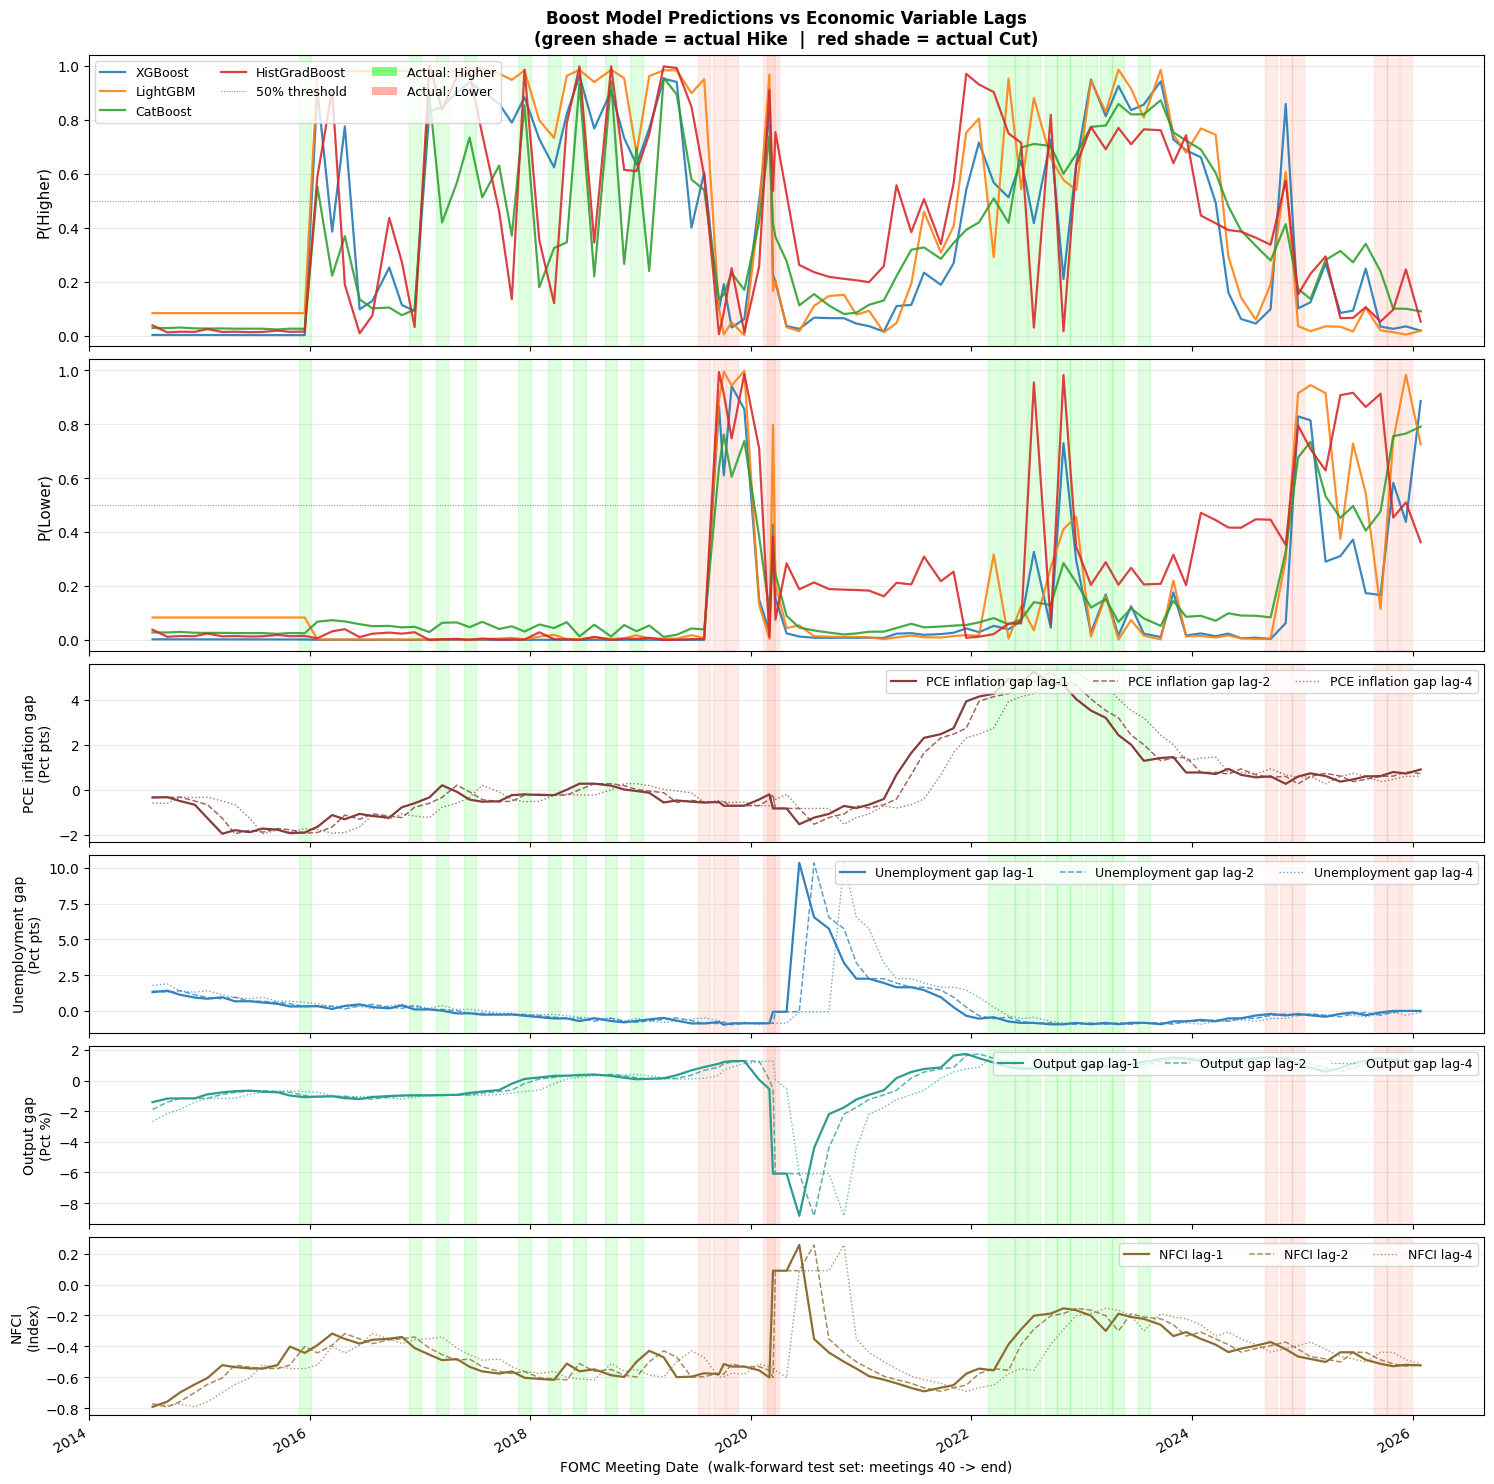

In [16]:
# -- 6b. Boost Models vs Economic Variable Lags --------------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

n_start = INITIAL_TRAIN_SIZE
test_dates = pd.to_datetime(meeting_dates[n_start:])
df_test = df_model.iloc[n_start:].copy().reset_index(drop=True)

actual_orig = np.array([INV_LABEL_MAP[a] for a in act_xgb])

_models = {
    'XGBoost': prob_xgb,
    'LightGBM': prob_lgbm,
    'CatBoost': prob_cat,
    'HistGradBoost': prob_hgb,
}
_clrs = {
    'XGBoost': '#1f77b4',
    'LightGBM': '#ff7f0e',
    'CatBoost': '#2ca02c',
    'HistGradBoost': '#d62728',
}

higher_mask = actual_orig == 1
lower_mask = actual_orig == -1


def _shade(ax):
    for d in test_dates[higher_mask]:
        ax.axvspan(d - pd.Timedelta(days=20), d + pd.Timedelta(days=20), alpha=0.12, color='lime', zorder=0)
    for d in test_dates[lower_mask]:
        ax.axvspan(d - pd.Timedelta(days=20), d + pd.Timedelta(days=20), alpha=0.12, color='tomato', zorder=0)


fig, axes = plt.subplots(
    6, 1,
    figsize=(18, 20),
    gridspec_kw={'height_ratios': [1.8, 1.8, 1.1, 1.1, 1.1, 1.1], 'hspace': 0.06},
    sharex=True,
)

ax = axes[0]
_shade(ax)
for name, proba in _models.items():
    ax.plot(test_dates, proba[:, 2], label=name, color=_clrs[name], lw=1.6, alpha=0.88)
ax.axhline(0.5, color='gray', lw=0.7, ls=':', label='50% threshold')
ax.set_ylim(-0.04, 1.04)
ax.set_ylabel('P(Higher)', fontsize=11)
ax.grid(axis='y', alpha=0.25)
ax.set_title(
    'Boost Model Predictions vs Economic Variable Lags\n'
    '(green shade = actual Hike  |  red shade = actual Cut)',
    fontsize=12, fontweight='bold', pad=8,
)
patches_legend = [
    mpatches.Patch(facecolor='lime', alpha=0.5, label='Actual: Higher'),
    mpatches.Patch(facecolor='tomato', alpha=0.5, label='Actual: Lower'),
]
h, l = ax.get_legend_handles_labels()
ax.legend(h + patches_legend, l + [p.get_label() for p in patches_legend], loc='upper left', fontsize=9, ncol=3)

ax = axes[1]
_shade(ax)
for name, proba in _models.items():
    ax.plot(test_dates, proba[:, 0], label=name, color=_clrs[name], lw=1.6, alpha=0.88)
ax.axhline(0.5, color='gray', lw=0.7, ls=':')
ax.set_ylim(-0.04, 1.04)
ax.set_ylabel('P(Lower)', fontsize=11)
ax.grid(axis='y', alpha=0.25)

lag_specs = [
    ('PCE_inflation_gap', 'PCE inflation gap', '#843c39', 'Pct pts'),
    ('unemployment_gap', 'Unemployment gap', '#3182bd', 'Pct pts'),
    ('output_gap_pct', 'Output gap', '#2a9d8f', 'Pct %'),
    ('NFCI', 'NFCI', '#8c6d31', 'Index'),
]
line_styles = [('-', 1.6, 1.00), ('--', 1.1, 0.78), (':', 1.0, 0.72)]
lag_nums = [1, 2, 4]

for axis_idx, (base_col, label, color, unit_label) in enumerate(lag_specs, start=2):
    ax = axes[axis_idx]
    _shade(ax)
    shades = [color, color, color]
    alphas = [1.0, 0.78, 0.72]
    for lag_num, (ls, lw, alpha) in zip(lag_nums, line_styles):
        col = f'{base_col}_lag{lag_num}'
        ax.plot(test_dates, df_test[col], color=color, lw=lw, ls=ls, alpha=alpha, label=f'{label} lag-{lag_num}')
    ax.set_ylabel(f'{label}\n({unit_label})', fontsize=10)
    ax.legend(loc='upper right', fontsize=9, ncol=3)
    ax.grid(axis='y', alpha=0.25)

axes[-1].set_xlabel('FOMC Meeting Date  (walk-forward test set: meetings 40 -> end)', fontsize=10)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

---
## 7. Calibration Check (Reliability Diagram)

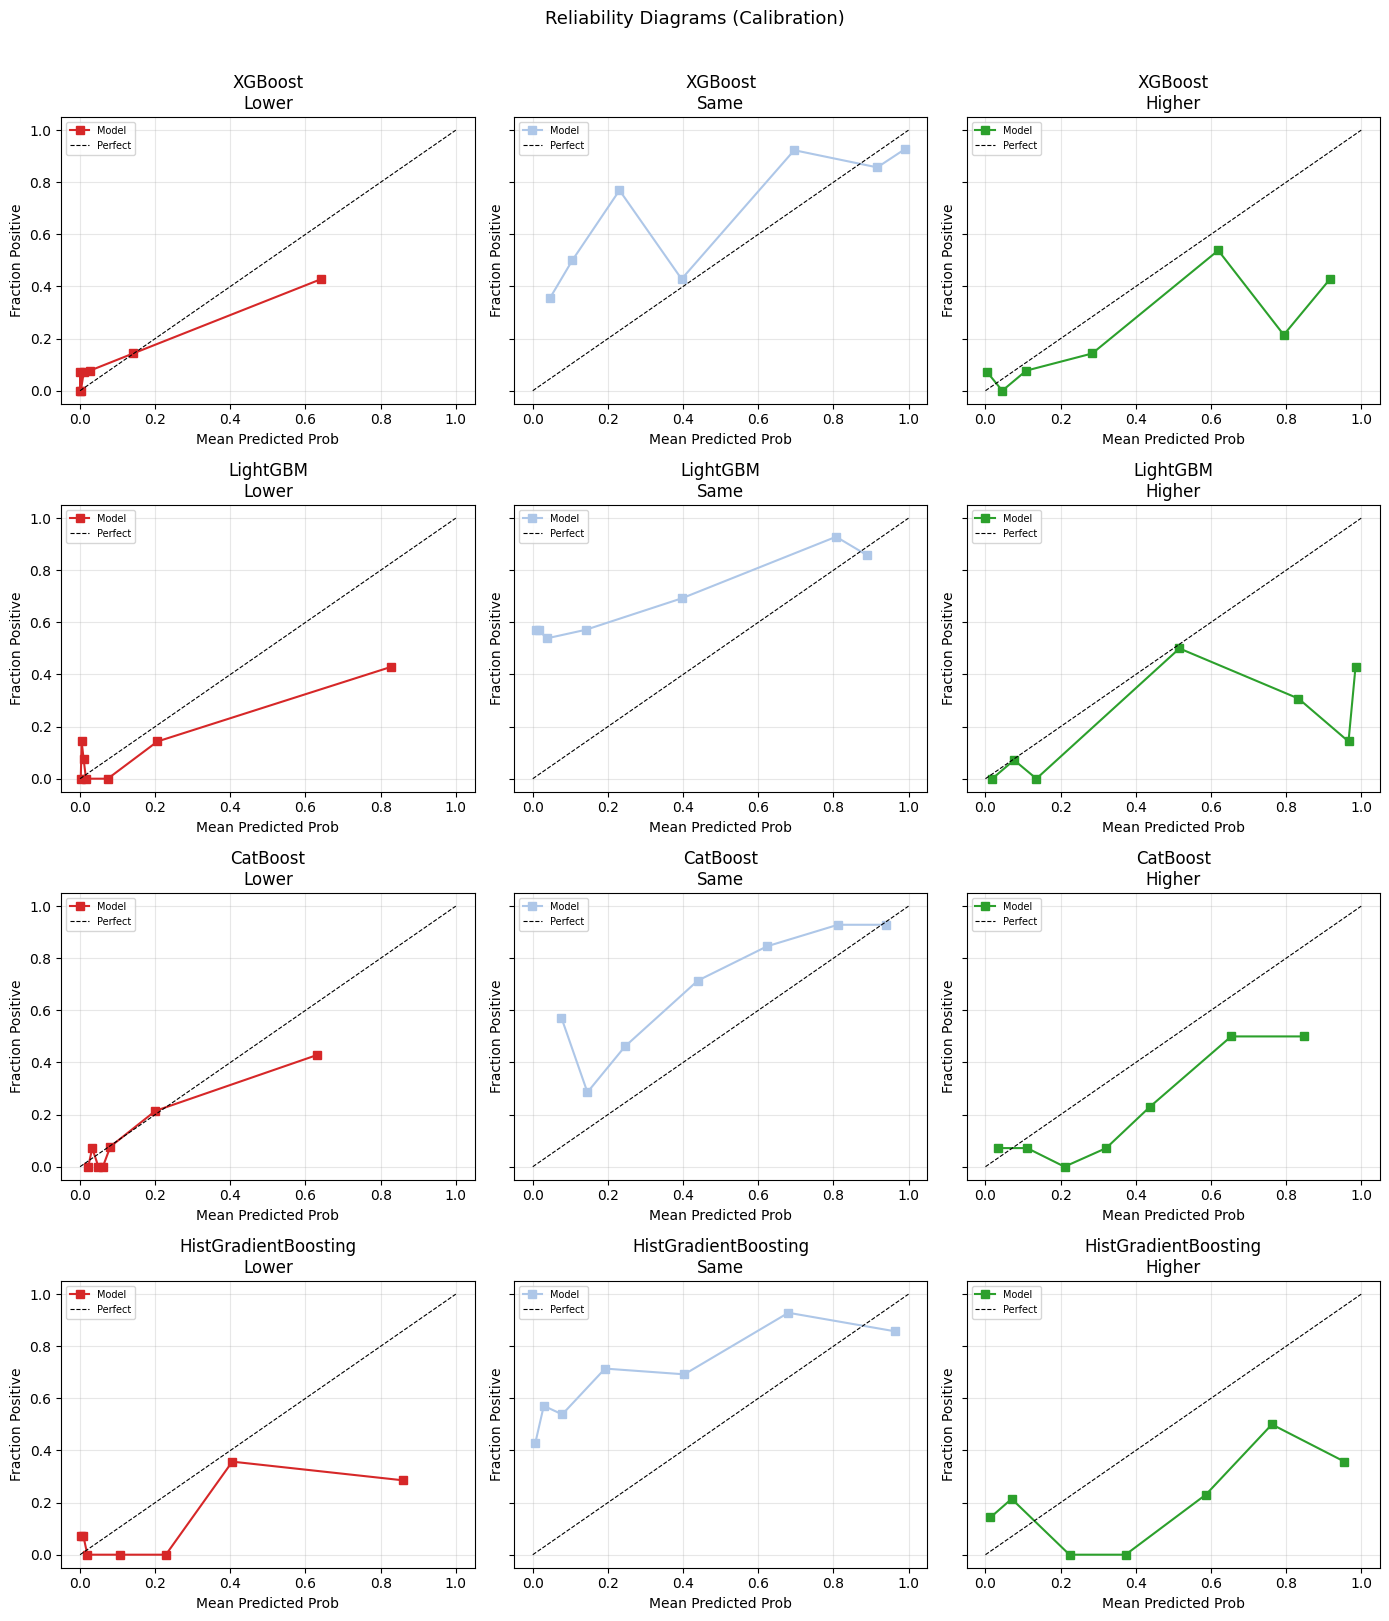

In [17]:
fig, axes = plt.subplots(len(final_results), 3,
                          figsize=(14, 4 * len(final_results)),
                          sharey=True)
if len(final_results) == 1:
    axes = [axes]

class_colors = ['#d62728', '#aec7e8', '#2ca02c']

for row_axes, (model_key, r) in zip(axes, final_results.items()):
    probs    = r['probas']
    act_enc  = r['actuals_enc']
    y_onehot = label_binarize(act_enc, classes=[0, 1, 2])

    for k, (ax, cls_name, color) in enumerate(zip(row_axes, LABEL_STRS, class_colors)):
        try:
            frac_pos, mean_pred = calibration_curve(
                y_onehot[:, k], probs[:, k], n_bins=7, strategy='quantile'
            )
            ax.plot(mean_pred, frac_pos, 's-', color=color, label='Model', linewidth=1.5)
        except ValueError:
            pass

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect')
        ax.set_title(f'{r["name"]}\n{cls_name}')
        ax.set_xlabel('Mean Predicted Prob')
        ax.set_ylabel('Fraction Positive')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

fig.suptitle('Reliability Diagrams (Calibration)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Regime-Learning Diagnostics

These charts ask a different question from Section 7.  
**Section 7** asks: *Was the model right?*  
**Section 8** asks: *Did the model learn the economic-policy structure in the `02` variable set?*

| Cell | Chart | What it reveals |
|------|-------|-----------------|
| 8-data | `df_regime` builder | Shared meeting-level structure for the diagnostics below |
| 8a | **Economic Backdrop + Probability Overlay** | Do model probabilities shift in sync with PCE gap, unemployment gap, output gap, and NFCI? |
| 8d | **Calibration Export** | Does the final calibrated likelihood layer look reusable downstream? |


In [18]:
# -- 8-data. Regime Data Builder -----------------------------------------------
# Build df_regime directly from the meeting-level lagged features used by the model.
# Columns:
#   date              - FOMC meeting date in the walk-forward test window
#   target_rate       - lagged upper bound fed funds rate available before the meeting
#   PCE_inflation_gap - lagged PCE inflation gap
#   unemployment_gap  - lagged unemployment gap
#   output_gap_pct    - lagged output gap percentage
#   NFCI              - lagged National Financial Conditions Index
#   {pfx}_pL/pS/pH    - P(Lower/Same/Higher) for each model
#   {pfx}_rs          - regime_score = P(Higher) - P(Lower)
#   actual_enc        - encoded true decision (0=Lower, 1=Same, 2=Higher)
#   actual_label      - string label

df_regime = df_model.iloc[INITIAL_TRAIN_SIZE:].copy().reset_index(drop=True)
df_regime = df_regime.rename(columns={
    'meeting_date': 'date',
    'target_rate_lag1': 'target_rate',
    'PCE_inflation_gap_lag1': 'PCE_inflation_gap',
    'unemployment_gap_lag1': 'unemployment_gap',
    'output_gap_pct_lag1': 'output_gap_pct',
    'NFCI_lag1': 'NFCI',
})

df_regime = df_regime[['date', 'target_rate', 'PCE_inflation_gap', 'unemployment_gap', 'output_gap_pct', 'NFCI']].copy()

_AVAIL = {}
if XGBOOST_AVAILABLE and 'XGBoost' in final_results:
    _AVAIL['XGBoost'] = ('xgb', final_results['XGBoost']['probas'])
if LGBM_AVAILABLE and 'LightGBM' in final_results:
    _AVAIL['LightGBM'] = ('lgb', final_results['LightGBM']['probas'])
if CATBOOST_AVAILABLE and 'CatBoost' in final_results:
    _AVAIL['CatBoost'] = ('cat', final_results['CatBoost']['probas'])
if 'HistGradientBoosting' in final_results:
    _AVAIL['HistGradBoost'] = ('hgb', final_results['HistGradientBoosting']['probas'])

_MODEL_CLRS = {
    'XGBoost': '#1f77b4',
    'LightGBM': '#ff7f0e',
    'CatBoost': '#2ca02c',
    'HistGradBoost': '#d62728',
}

for _mname, (_pfx, _probs) in _AVAIL.items():
    _n = min(len(_probs), len(df_regime))
    df_regime.loc[df_regime.index[:_n], f'{_pfx}_pL'] = _probs[:_n, 0]
    df_regime.loc[df_regime.index[:_n], f'{_pfx}_pS'] = _probs[:_n, 1]
    df_regime.loc[df_regime.index[:_n], f'{_pfx}_pH'] = _probs[:_n, 2]
    df_regime.loc[df_regime.index[:_n], f'{_pfx}_rs'] = _probs[:_n, 2] - _probs[:_n, 0]

_acts_enc = final_results[
    'XGBoost' if 'XGBoost' in final_results else
    'HistGradientBoosting' if 'HistGradientBoosting' in final_results else
    list(final_results.keys())[0]
]['actuals_enc']
_n_act = min(len(_acts_enc), len(df_regime))
df_regime.loc[df_regime.index[:_n_act], 'actual_enc'] = _acts_enc[:_n_act].astype(float)
df_regime.loc[df_regime.index[:_n_act], 'actual_label'] = [ENCODED_NAMES[int(e)] for e in _acts_enc[:_n_act]]

_PRIMARY = 'XGBoost' if 'XGBoost' in _AVAIL else list(_AVAIL.keys())[0]
_PPFX = _AVAIL[_PRIMARY][0]

print(
    f'df_regime : {len(df_regime)} test meetings  '
    f'({df_regime["date"].min().date()} -> {df_regime["date"].max().date()})'
)
print(
    'Feature cols available: '
    f'target_rate={df_regime["target_rate"].notna().sum()} | '
    f'PCE_gap={df_regime["PCE_inflation_gap"].notna().sum()} | '
    f'unemp_gap={df_regime["unemployment_gap"].notna().sum()} | '
    f'output_gap={df_regime["output_gap_pct"].notna().sum()} | '
    f'NFCI={df_regime["NFCI"].notna().sum()}'
)
print(f'Models registered : {list(_AVAIL.keys())}')
print(f'Primary (single-model charts): {_PRIMARY}')

df_regime : 96 test meetings  (2014-07-30 -> 2026-01-28)
Feature cols available: target_rate=96 | PCE_gap=96 | unemp_gap=96 | output_gap=96 | NFCI=96
Models registered : ['XGBoost', 'LightGBM', 'CatBoost', 'HistGradBoost']
Primary (single-model charts): XGBoost


### 8a. Economic Backdrop + Model Probability Overlay

**What to look for:**
- When the **PCE inflation gap** rises, does **P(Higher)** rise too?
- When the **unemployment gap** deteriorates or **NFCI** tightens, does **P(Lower)** respond?
- Do probability transitions precede or lag changes in the economic variables actually used by the model?
- The coloured shading marks known Fed policy regimes, so probabilities should remain directionally consistent within each band.

Each model is one line; good regime capture means the probability lines move together and in an economically coherent direction.

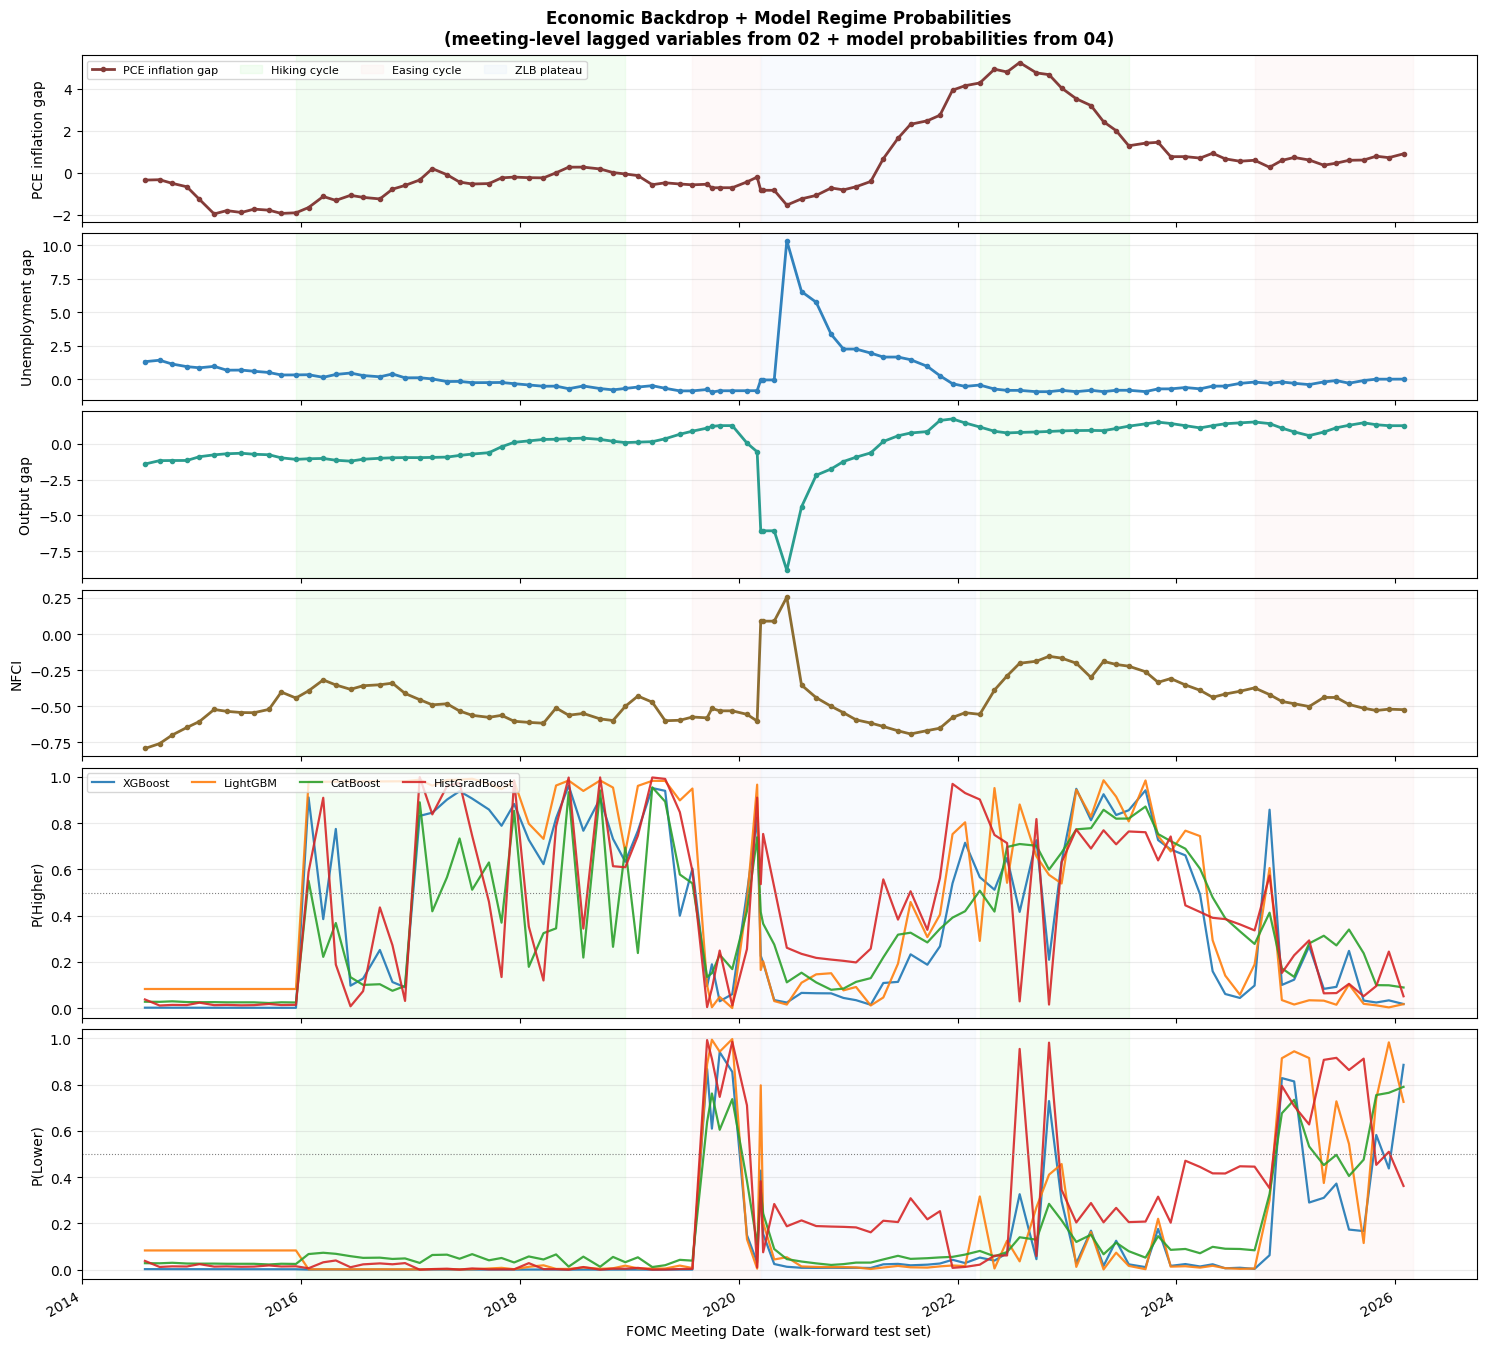

In [19]:
# -- 8a. Economic Backdrop + Model Probability Overlay ------------------------
# Meeting-level backdrop using the same lagged variables that entered the model.

def plot_macro_backdrop(df_r, avail, model_clrs):
    _SHADES = [
        ('2015-12-16', '2018-12-19', 'Hiking cycle', '#c8f7c5', 0.22),
        ('2019-07-31', '2020-03-14', 'Easing cycle', '#fce4e4', 0.22),
        ('2020-03-15', '2022-02-28', 'ZLB plateau', '#dde8fb', 0.20),
        ('2022-03-17', '2023-07-26', 'Hiking cycle', '#c8f7c5', 0.22),
        ('2024-09-18', '2026-03-01', 'Easing cycle', '#fce4e4', 0.22),
    ]

    fig, axes = plt.subplots(
        6, 1, figsize=(18, 18), sharex=True,
        gridspec_kw={'height_ratios': [1.2, 1.2, 1.2, 1.2, 1.8, 1.8], 'hspace': 0.06}
    )

    import matplotlib.patches as mpatches
    _shade_handles = {}

    for ax in axes:
        for s0, s1, lab, clr, a in _SHADES:
            span = ax.axvspan(pd.to_datetime(s0), pd.to_datetime(s1), color=clr, alpha=a, zorder=0)
            if lab not in _shade_handles:
                _shade_handles[lab] = mpatches.Patch(color=clr, alpha=a, label=lab)

    macro_panels = [
        ('PCE_inflation_gap', 'PCE inflation gap', '#843c39'),
        ('unemployment_gap', 'Unemployment gap', '#3182bd'),
        ('output_gap_pct', 'Output gap', '#2a9d8f'),
        ('NFCI', 'NFCI', '#8c6d31'),
    ]

    for idx, (col, label, color) in enumerate(macro_panels):
        ax = axes[idx]
        ax.plot(df_r['date'], df_r[col], color=color, lw=2.0, marker='o', ms=3.0, label=label)
        ax.set_ylabel(label, fontsize=10)
        ax.grid(axis='y', alpha=0.25)
        if idx == 0:
            _leg_macro = ax.get_legend_handles_labels()
            ax.legend(
                _leg_macro[0] + list(_shade_handles.values()),
                _leg_macro[1] + list(_shade_handles.keys()),
                loc='upper left', fontsize=8, ncol=4,
            )
            ax.set_title(
                'Economic Backdrop + Model Regime Probabilities\n'
                '(meeting-level lagged variables from 02 + model probabilities from 04)',
                fontsize=12, fontweight='bold', pad=8,
            )

    prob_specs = [
        ('pH', 'P(Higher)', 2, axes[4]),
        ('pL', 'P(Lower)', 0, axes[5]),
    ]
    for suffix, label, idx, ax in prob_specs:
        for model_name, (pfx, _) in avail.items():
            ax.plot(
                df_r['date'], df_r[f'{pfx}_{suffix}'],
                color=model_clrs[model_name], lw=1.6, alpha=0.9, label=model_name,
            )
        ax.set_ylabel(label, fontsize=10)
        ax.set_ylim(-0.04, 1.04)
        ax.grid(axis='y', alpha=0.25)
        ax.axhline(0.5, color='gray', lw=0.8, ls=':')
        if label == 'P(Higher)':
            ax.legend(loc='upper left', fontsize=8, ncol=4)

    axes[-1].set_xlabel('FOMC Meeting Date  (walk-forward test set)', fontsize=10)
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()


plot_macro_backdrop(df_regime, _AVAIL, _MODEL_CLRS)

---
## 9. Decile Calibration Curves and Export

This section converts the walk-forward probability outputs into a reusable decile-based calibration map.

For each model and class:
- predicted probabilities are grouped into fixed decile buckets
- the realized hit rate is computed inside each bucket
- the calibration table is exported to `calibration_map.csv`

The exported mapping is later consumed by `05_bayesian_update.ipynb`.


Calibration map saved to /Users/echohuang/Documents/forecasting_fed_rate/analysis/calibration_map.csv


,model,class,bucket_low,bucket_high,predicted_mean,actual_freq,count
0,XGBoost,Lower,0.0,0.1,0.010942,0.054795,73
1,XGBoost,Lower,0.1,0.2,0.159259,0.142857,7
2,XGBoost,Lower,0.2,0.3,0.293069,0.000000,2
3,XGBoost,Lower,0.3,0.4,0.336602,0.000000,3
4,XGBoost,Lower,0.4,0.5,0.433083,1.000000,2
5,XGBoost,Lower,0.5,0.6,0.582638,1.000000,1
6,XGBoost,Lower,0.6,0.7,0.609980,0.000000,1
7,XGBoost,Lower,0.7,0.8,0.729254,0.000000,1
8,XGBoost,Lower,0.8,0.9,0.850339,0.400000,5
9,XGBoost,Lower,0.9,1.0,0.940791,1.000000,1


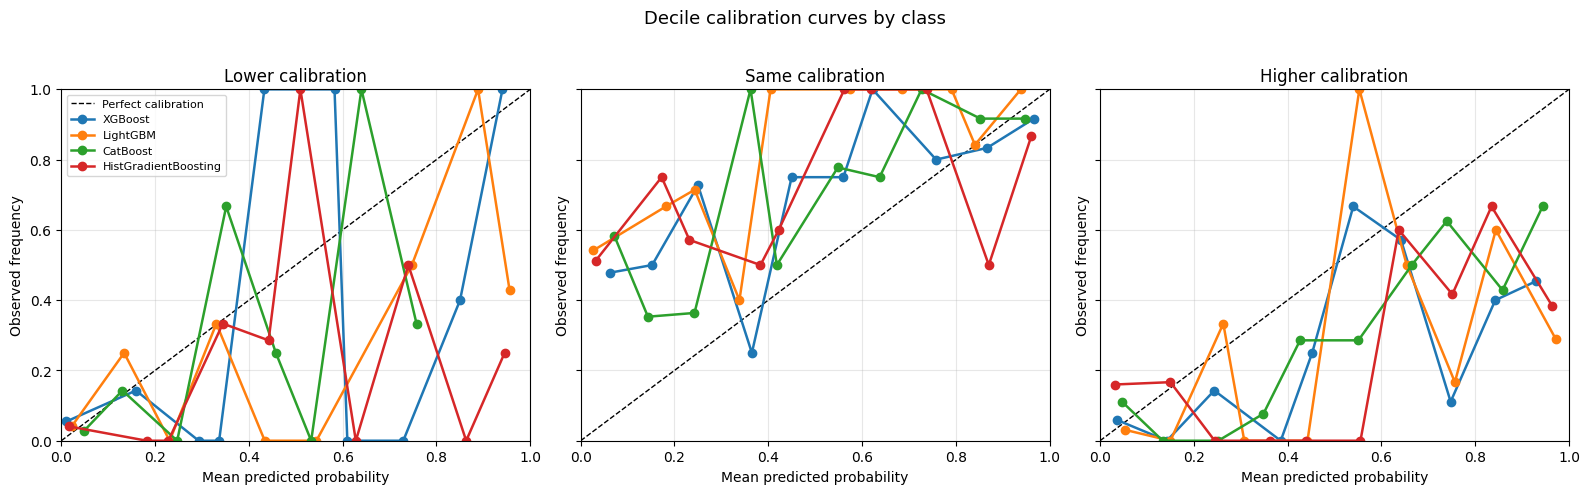

In [20]:
# ── 9. Decile calibration map + multi-model calibration curves ───────────────
from pathlib import Path

CALIBRATION_BUCKETS = np.linspace(0.0, 1.0, 11)
CLASS_ORDER = ['Lower', 'Same', 'Higher']


def assign_decile_bucket(prob):
    bucket_idx = min(int(np.floor(prob * 10)), 9)
    bucket_low = bucket_idx / 10
    bucket_high = bucket_low + 0.1
    return bucket_low, bucket_high


calibration_rows = []
for model_name, result in final_results.items():
    probs = np.asarray(result['probas'], dtype=float)
    acts = np.asarray(result['actuals_enc'], dtype=int)
    y_onehot = label_binarize(acts, classes=[0, 1, 2])

    for class_idx, class_name in enumerate(CLASS_ORDER):
        class_probs = probs[:, class_idx]
        bucket_idx = np.minimum((class_probs * 10).astype(int), 9)

        for decile in range(10):
            bucket_low = decile / 10
            bucket_high = bucket_low + 0.1
            mask = bucket_idx == decile
            count = int(mask.sum())

            predicted_mean = float(class_probs[mask].mean()) if count else np.nan
            actual_freq = float(y_onehot[mask, class_idx].mean()) if count else np.nan

            calibration_rows.append({
                'model': model_name,
                'class': class_name,
                'bucket_low': bucket_low,
                'bucket_high': bucket_high,
                'predicted_mean': predicted_mean,
                'actual_freq': actual_freq,
                'count': count,
            })

df_calibration = pd.DataFrame(calibration_rows)
calibration_out = Path('calibration_map.csv')
df_calibration.to_csv(calibration_out, index=False)

print(f'Calibration map saved to {calibration_out.resolve()}')
display(df_calibration.head(12))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
palette = sns.color_palette('tab10', n_colors=len(final_results))

for class_idx, class_name in enumerate(CLASS_ORDER):
    ax = axes[class_idx]
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.0, label='Perfect calibration')

    for color, (model_name, _) in zip(palette, final_results.items()):
        df_plot = (
            df_calibration[
                (df_calibration['model'] == model_name) &
                (df_calibration['class'] == class_name) &
                (df_calibration['count'] > 0)
            ]
            .sort_values('bucket_low')
        )
        if df_plot.empty:
            continue

        ax.plot(
            df_plot['predicted_mean'],
            df_plot['actual_freq'],
            marker='o',
            linewidth=1.8,
            color=color,
            label=model_name,
        )

    ax.set_title(f'{class_name} calibration')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed frequency')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Decile calibration curves by class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
